In [164]:
import pandas as pd
import numpy as np

from math import isnan
import multiprocessing as mp
import matplotlib.pyplot as plt
import json
from protocols import utils, functions, graphs
from matplotlib_venn import venn2
from functools import partial
from joblib import Memory
from multiprocessing import Pool, get_context

import gumpy


%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### Compare WHOv1 vs catomatic (CRyPTIC 1), as trained on same data

In [ ]:
opt_cats_v1 = pd.read_csv('results/grid_search/opt_cats_v3.3.0_train.csv')

def load_who_catalogue(path):
    #Prep data for comparisons:
    who = pd.read_csv(path)
    who['EVIDENCE'] = who['EVIDENCE'].apply(utils.str_to_dict)
    who['GENBANK_REFERENCE'] = 'NC00962.3'
    who['CATALOGUE_VERSION'] = 0
    who['CATALOGUE_NAME'] = '-'
    #filter out default rules
    who = who[~who['EVIDENCE'].apply(lambda x: isinstance(x, dict) and 'reporting_rule' in x)]
    return who

who = load_who_catalogue('catalogues/whov1/NC_000962.3_WHO-UCN-GTB-PCI-2021.7_v1.2_GARC1_RUS.csv')
who['solo_R'] = who['EVIDENCE'].apply(lambda x: utils.extract_value(x, 'Present_R'))
who['solo_S'] = who['EVIDENCE'].apply(lambda x: utils.extract_value(x, 'Present_S'))
who['TOTAL'] = who['solo_R'] + who['solo_S']
who['PROPORTION'] = who['solo_R']/(who['solo_R']+who['solo_S'])
who['CONFIDENCE'] = who.apply(utils.wilson_ci, R_col='solo_R', S_col='solo_S', axis=1)
u_who = who[~who.PREDICTION.isin(['R','S'])]
who = who[who.PREDICTION.isin(['R','S'])]

def load_catomatic_catalogues(opt_path, base_path):
    """Load and process catomatic catalogues from optimal parameter settings."""
    opt_df = pd.read_csv(opt_path)
    valid_drugs = opt_df

    # Load catalogue files based on optimal settings
    catalogue_dfs = valid_drugs.apply(
        lambda row: pd.read_csv(
            f"{base_path}/{row['DRUG'].lower()}/bg_{row['BACKGROUND_RATE']}_p_{row['p_value']}_FRS_0.1.csv"
        ),
        axis=1
    ).tolist()

    cat_df = pd.concat(catalogue_dfs)
    cat_df['CATALOGUE_VERSION'] = 0
    cat_df['CATALOGUE_NAME'] = '-'

    # Parse evidence
    cat_df['EVIDENCE'] = cat_df['EVIDENCE'].apply(utils.str_to_dict)
    cat_df = cat_df[~cat_df['EVIDENCE'].apply(lambda x: isinstance(x, dict) and 'default_rule' in x)]

    # Extract key metrics
    cat_df['solo_R'] = cat_df['EVIDENCE'].apply(lambda x: utils.extract_value(x, 'contingency', 0, 0))
    cat_df['solo_S'] = cat_df['EVIDENCE'].apply(lambda x: utils.extract_value(x, 'contingency', 0, 1))
    cat_df['TOTAL'] = cat_df['solo_R'] + cat_df['solo_S']
    cat_df['PROPORTION'] = cat_df['EVIDENCE'].apply(lambda x: utils.extract_value(x, 'proportion'))
    cat_df['CONFIDENCE'] = cat_df['EVIDENCE'].apply(lambda x: utils.extract_value(x, 'confidence'))

    # Keep only R and S predictions
    unknown = cat_df[~cat_df.PREDICTION.isin(['R', 'S'])]
    cat_df = cat_df[cat_df.PREDICTION.isin(['R', 'S'])]

    return cat_df, unknown

# Load both catalogue sets
cat, u_cat = load_catomatic_catalogues(
    'results/grid_search/opt_cats_v3.3.0_train.csv',
    './catalogues/cryptic-v3.3.0/grid_search'
)

valid_drugs = cat[cat.DRUG.isin(who.DRUG.unique())].DRUG.unique()

/Users/dylanadlard/Documents/Oxford/PhD/Projects/cryptic-catalogues-2025/protocols/utils.py:596: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  }
/Users/dylanadlard/Documents/Oxford/PhD/Projects/cryptic-catalogues-2025/protocols/utils.py:606: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cat2_no_rules = cat2[(~cat2["MUTATION"].str.contains(r"[*?=]", regex=True))&(~cat2['MUTATION'].str.contains('indel'))]


RIF


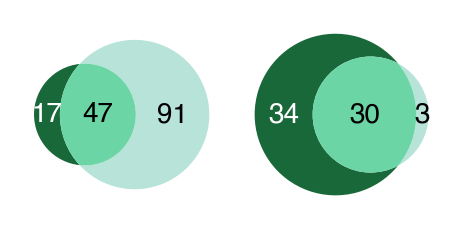

INH


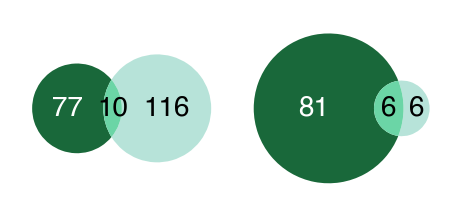

STM


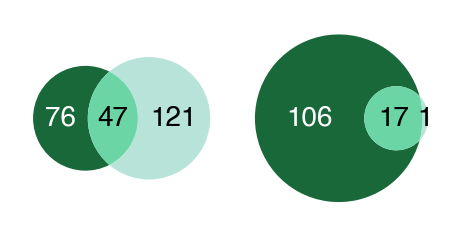

MXF


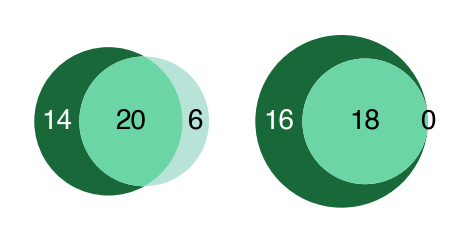

LEV


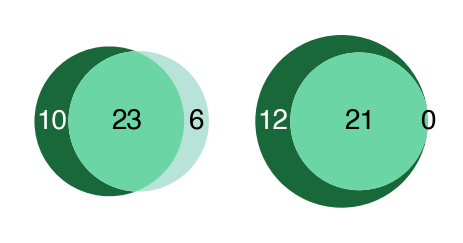

EMB


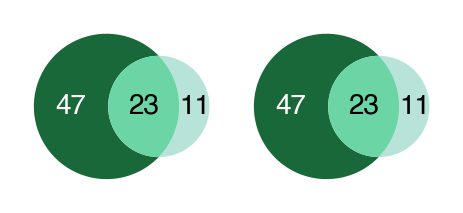

PZA


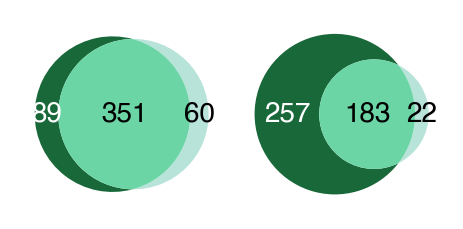

AMI


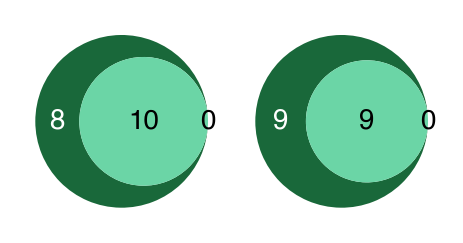

CAP


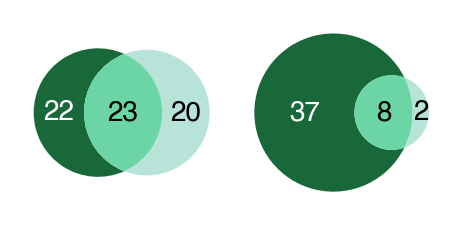

ETH


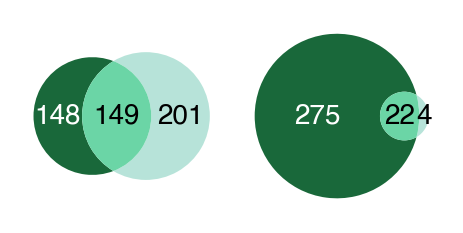

KAN


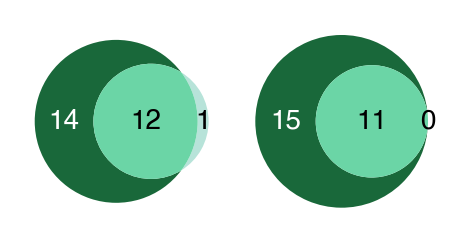

LZD


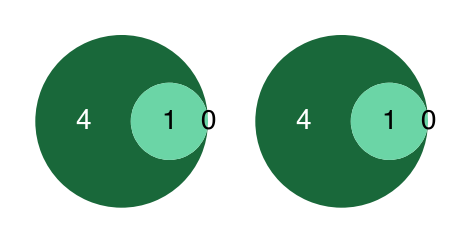

DLM


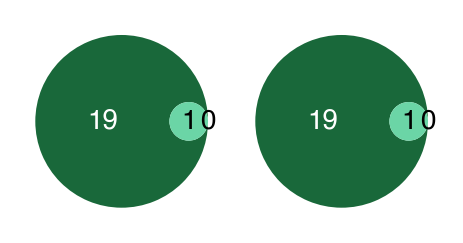

In [167]:
expanded_catalogues = utils.expand_catalogue_pair(cat, who, valid_drugs, 'RUS', ('cat', 'who'), who_cat='WHOv1')

catalogue_palette = {
    "catomatic_v1": "#70c0b3", 
    "catomatic_v3": "#018571",  
    "WHOv1": "#d5b477",        
    "WHOv2": "#a6611a",        
}


# Plot diagrams with and without rules
graphs.plot_venn_pair_per_drug(expanded_catalogues, valid_drugs,  'figs/discordance/')


### Summary table including rules

In [170]:
all_drugs_merged = pd.concat(expanded_catalogues[drug]['merged'] for drug in valid_drugs)
suffixes = ('cat', 'who')
all_drugs_merged['PREDICTION_PAIR'] = all_drugs_merged.apply(utils.classify_predictions, axis=1, args=(suffixes,))
all_drugs_merged['DRUG'] = all_drugs_merged['DRUG_who'].combine_first(all_drugs_merged['DRUG_cat'])

summary_table = (
    all_drugs_merged.drop_duplicates(['DRUG', 'MUTATION']).groupby(['DRUG', 'PREDICTION_PAIR'])
    .size()
    .unstack(fill_value=0)  # Pivot table to create columns for prediction pairs
    .reset_index()  # Resets the index, moving 'PREDICTION_PAIR' into a column
)

summary_table.rename(columns={'DRUG': 'DRUG'}, inplace=True)
summary_table['total'] = summary_table.drop(columns=['DRUG']).sum(axis=1)
summary_table.columns.name = None

print ('Prediction pairs comparing catomatic_v1 with WHOv1, including rules:')
summary_table

Prediction pairs comparing catomatic_v1 with WHOv1, including rules:


,DRUG,R.R,R.S,R.U,S.R,S.S,S.U,U.R,U.S,total
0,AMI,4,0,8,0,6,0,0,0,18
1,CAP,21,0,22,0,2,0,18,2,65
2,DLM,1,0,19,0,0,0,0,0,20
3,EMB,12,0,4,0,11,43,3,8,81
4,ETH,149,0,147,0,0,1,201,0,498
5,INH,9,0,55,0,1,22,113,3,203
6,KAN,8,1,13,0,3,1,0,1,27
7,LEV,10,0,3,0,13,7,4,2,39
8,LZD,1,0,0,0,0,4,0,0,5
9,MXF,10,0,1,0,10,13,4,2,40


In [171]:
def nan_friendly_filter(series, value):
    if pd.isna(value):
        return series.isna()
    else:
        return series == value

# Example usage:
drug = "RIF"
cat_pheno = 'S'
who_pheno = np.nan
#np.nan

all_drugs_merged[
    (all_drugs_merged.DRUG==drug) &
    nan_friendly_filter(all_drugs_merged.PREDICTION_who, who_pheno) &
    nan_friendly_filter(all_drugs_merged.PREDICTION_cat, cat_pheno)
]

,Unnamed: 0_cat,GENBANK_REFERENCE_cat,CATALOGUE_NAME_cat,CATALOGUE_VERSION_cat,CATALOGUE_GRAMMAR_cat,PREDICTION_VALUES_cat,DRUG_cat,MUTATION,PREDICTION_cat,SOURCE_cat,...,EVIDENCE_who,OTHER_who,Unnamed: 0_who,solo_R_who,solo_S_who,TOTAL_who,PROPORTION_who,CONFIDENCE_who,PREDICTION_PAIR,DRUG
51,15.0,NC00962.3,-,0.0,GARC1,RUS,RIF,rpoB@A686T,S,{},...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,S.U,RIF
52,17.0,NC00962.3,-,0.0,GARC1,RUS,RIF,rpoB@A692T,S,{},...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,S.U,RIF
65,14.0,NC00962.3,-,0.0,GARC1,RUS,RIF,rpoB@D515Y,S,{},...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,S.U,RIF
66,10.0,NC00962.3,-,0.0,GARC1,RUS,RIF,rpoB@D545E,S,{},...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,S.U,RIF
68,3.0,NC00962.3,-,0.0,GARC1,RUS,RIF,rpoB@E563D,S,{},...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,S.U,RIF
73,22.0,NC00962.3,-,0.0,GARC1,RUS,RIF,rpoB@G945E,S,{},...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,S.U,RIF
74,13.0,NC00962.3,-,0.0,GARC1,RUS,RIF,rpoB@H343Q,S,{},...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,S.U,RIF
114,7.0,NC00962.3,-,0.0,GARC1,RUS,RIF,rpoB@M390T,S,{},...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,S.U,RIF
118,11.0,NC00962.3,-,0.0,GARC1,RUS,RIF,rpoB@M655T,S,{},...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,S.U,RIF
125,21.0,NC00962.3,-,0.0,GARC1,RUS,RIF,rpoB@P358L,S,{},...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,S.U,RIF


### Summary table exlcuding rules

In [172]:
all_drugs_who = pd.concat(expanded_catalogues[drug]['who'] for drug in valid_drugs)
all_drugs_who = all_drugs_who[all_drugs_who.PREDICTION!='U']
all_drugs_cat = pd.concat(expanded_catalogues[drug]['cat'] for drug in valid_drugs)
all_drugs_cat = all_drugs_cat[all_drugs_cat.PREDICTION!='U']

suffixes = ('_cat', '_who')

all_drugs_merged = pd.merge(all_drugs_cat, all_drugs_who, on=['DRUG', 'MUTATION'], how='outer', suffixes=suffixes)
suffixes = ('cat', 'who')

all_drugs_merged['PREDICTION_PAIR'] = all_drugs_merged.apply(utils.classify_predictions, axis=1, args=(suffixes,))
all_drugs_merged = all_drugs_merged[all_drugs_merged.EVIDENCE_who!={'expanded_rule'}]

summary_table = (
    all_drugs_merged.drop_duplicates(['DRUG', 'MUTATION']).groupby(['DRUG', 'PREDICTION_PAIR'])
    .size()
    .unstack(fill_value=0)  # Pivot table to create columns for prediction pairs
    .reset_index()  # Resets the index, moving 'PREDICTION_PAIR' into a column
)

summary_table.rename(columns={'DRUG': 'DRUG'}, inplace=True)
summary_table['total'] = summary_table.drop(columns=['DRUG']).sum(axis=1)
summary_table.columns.name = None

print ('Prediction pairs comparing catomatic_v1 with WHOv1, excluding rules:')
summary_table

Prediction pairs comparing catomatic_v1 with WHOv1, excluding rules:


,DRUG,R.R,R.S,R.U,S.S,S.U,U.R,U.S,U.U,total
0,AMI,3,0,9,6,0,0,0,0,18
1,CAP,6,0,36,2,0,0,2,0,46
2,DLM,1,0,19,0,0,0,0,0,20
3,EMB,12,0,4,11,43,3,8,0,81
4,ETH,22,0,236,0,1,4,0,0,263
5,INH,5,0,59,1,22,3,3,0,93
6,KAN,7,1,14,3,1,0,0,0,26
7,LEV,8,0,5,13,7,0,0,0,33
8,LZD,1,0,0,0,4,0,0,0,5
9,MXF,8,0,3,10,13,0,0,0,34


In [173]:
def nan_friendly_filter(series, value):
    if pd.isna(value):
        return series.isna()
    else:
        return series == value

drug = "RIF"
cat_pheno = 'R'
who_pheno = np.nan 
#np.nan

all_drugs_merged[
    (all_drugs_merged.DRUG == drug) &
    nan_friendly_filter(all_drugs_merged.PREDICTION_who, who_pheno) &
    nan_friendly_filter(all_drugs_merged.PREDICTION_cat, cat_pheno)
]

,Unnamed: 0_cat,GENBANK_REFERENCE_cat,CATALOGUE_NAME_cat,CATALOGUE_VERSION_cat,CATALOGUE_GRAMMAR_cat,PREDICTION_VALUES_cat,DRUG,MUTATION,PREDICTION_cat,SOURCE_cat,...,SOURCE_who,EVIDENCE_who,OTHER_who,Unnamed: 0_who,solo_R_who,solo_S_who,TOTAL_who,PROPORTION_who,CONFIDENCE_who,PREDICTION_PAIR
1120,42.0,NC00962.3,-,0.0,GARC1,RUS,RIF,rpoB@1263_del_caaggagttcttcggcac,R,{},...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,R.U
1121,106.0,NC00962.3,-,0.0,GARC1,RUS,RIF,rpoB@1292_ins_cca,R,{},...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,R.U
1122,179.0,NC00962.3,-,0.0,GARC1,RUS,RIF,rpoB@1293_del_ccaattcatgga,R,{},...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,R.U
1123,181.0,NC00962.3,-,0.0,GARC1,RUS,RIF,rpoB@1294_del_caa,R,{},...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,R.U
1124,277.0,NC00962.3,-,0.0,GARC1,RUS,RIF,rpoB@1295_del_aattcatgg,R,{},...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,R.U
1126,180.0,NC00962.3,-,0.0,GARC1,RUS,RIF,rpoB@1299_del_catgga,R,{},...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,R.U
1128,72.0,NC00962.3,-,0.0,GARC1,RUS,RIF,rpoB@1304_del_acc,R,{},...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,R.U
1129,107.0,NC00962.3,-,0.0,GARC1,RUS,RIF,rpoB@1304_del_accaga,R,{},...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,R.U
1130,95.0,NC00962.3,-,0.0,GARC1,RUS,RIF,rpoB@1306_del_cag,R,{},...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,R.U
1131,32.0,NC00962.3,-,0.0,GARC1,RUS,RIF,rpoB@1309_del_aac,R,{},...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,R.U


# Compare catomatic on training set vs catomatic on entire dataset

In [184]:
# Load both catalogue sets
cat, u_cat = load_catomatic_catalogues(
    'results/grid_search/opt_cats_v3.3.0_train.csv',
    './catalogues/cryptic-v3.3.0/grid_search'
)

cats_all, u_cats_all = load_catomatic_catalogues(
    'results/grid_search/all-samples/opt_cats_v3.3.0.csv',
    './catalogues/cryptic-v3.3.0/all-samples/grid_search'
)

In [185]:
cats_all

,Unnamed: 0,GENBANK_REFERENCE,CATALOGUE_NAME,CATALOGUE_VERSION,CATALOGUE_GRAMMAR,PREDICTION_VALUES,DRUG,MUTATION,PREDICTION,SOURCE,EVIDENCE,OTHER,solo_R,solo_S,TOTAL,PROPORTION,CONFIDENCE
0,0,NC00962.3,-,0,GARC1,RUS,RIF,rpoB@c-61t,S,{},"{'proportion': 0.01069402007856831, 'confidenc...",{},49.0,4533.0,4582.0,0.010694,"[0.008467481050231518, 0.013498061229333141]"
1,1,NC00962.3,-,0,GARC1,RUS,RIF,rpoB@2546_ins_cgagga,S,{},"{'proportion': 0.0, 'confidence': [-3.33282421...",{},0.0,66.0,66.0,0.000000,"[-3.332824213550257e-18, 0.039378823280876614]"
2,2,NC00962.3,-,0,GARC1,RUS,RIF,rpoB@S16C,S,{},"{'proportion': 0.0, 'confidence': [0.0, 0.1372...",{},0.0,17.0,17.0,0.000000,"[0.0, 0.13729859622486673]"
3,3,NC00962.3,-,0,GARC1,RUS,RIF,rpoB@E563D,S,{},"{'proportion': 0.0, 'confidence': [0.0, 0.2129...",{},0.0,10.0,10.0,0.000000,"[0.0, 0.21294197008340696]"
4,4,NC00962.3,-,0,GARC1,RUS,RIF,rpoB@E250G,S,{},"{'proportion': 0.050505050505050504, 'confiden...",{},5.0,94.0,99.0,0.050505,"[0.02479748764159554, 0.10012730035513771]"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22,127,NC00962.3,-,0,GARC1,RUS,DLM,ddn@W88R,R,{},"{'proportion': 1.0, 'confidence': [0.269865948...",{},1.0,0.0,1.0,1.000000,"[0.26986594878405434, 1.0000000000000002]"
23,142,NC00962.3,-,0,GARC1,RUS,DLM,ddn@V61G,R,{},"{'proportion': 0.5, 'confidence': [0.120866319...",{},1.0,1.0,2.0,0.500000,"[0.12086631942227369, 0.8791336805777263]"
24,144,NC00962.3,-,0,GARC1,RUS,DLM,ddn@P2Q,R,{},"{'proportion': 1.0, 'confidence': [0.425030609...",{},2.0,0.0,2.0,1.000000,"[0.4250306090063464, 1.0]"
25,152,NC00962.3,-,0,GARC1,RUS,DLM,ddn@3_del_gccgaaatcaccgccgcggtttctgaattcgccgct...,R,{},"{'proportion': 0.5, 'confidence': [0.120866319...",{},1.0,1.0,2.0,0.500000,"[0.12086631942227369, 0.8791336805777263]"


RIF


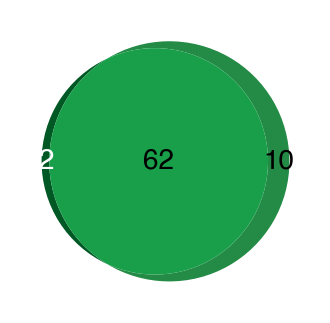

INH


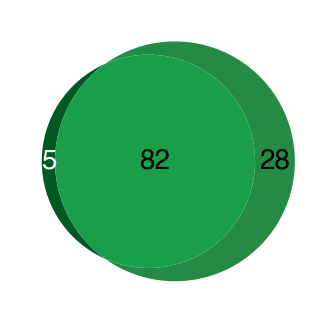

STM


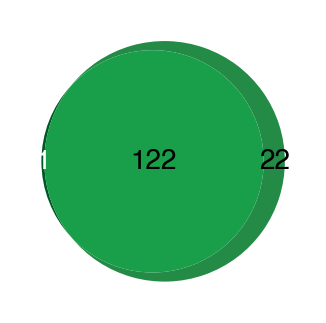

MXF


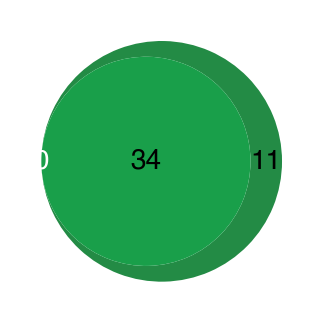

LEV


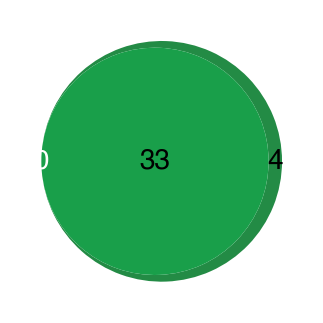

EMB


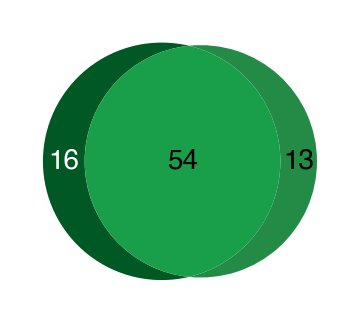

PZA


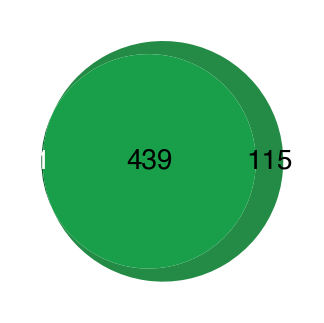

AMI


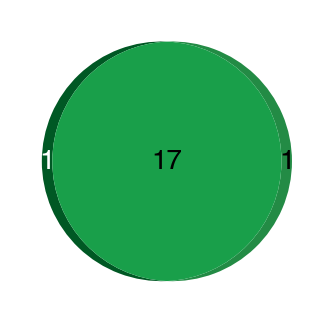

CAP


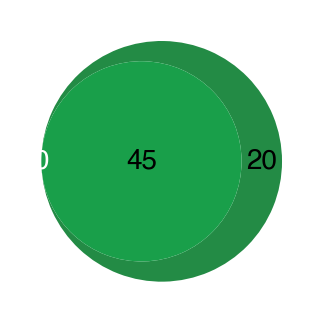

ETH


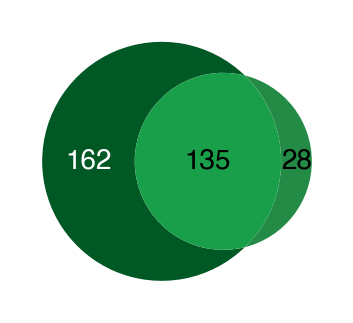

KAN


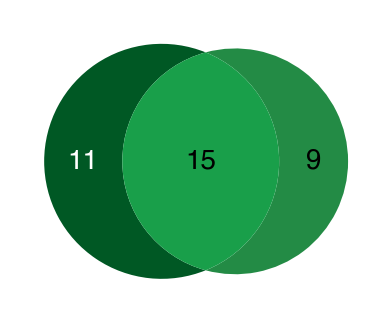

LZD


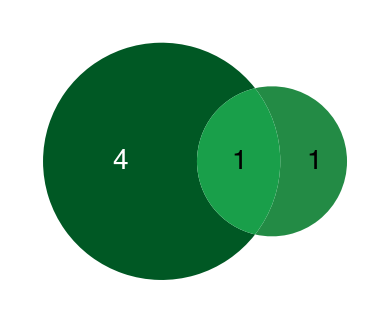

DLM


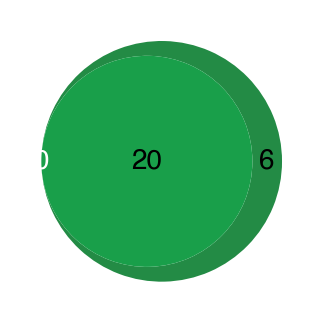

In [193]:
expanded_catalogues = utils.expand_catalogue_pair(cat, cats_all, valid_drugs, 'RUS', ('cat', 'cat_all'), who_cat=None)
# Plot diagrams with and without rules
graphs.plot_venn_catomatic_per_drug(expanded_catalogues, valid_drugs,  'figs/discordance/')


In [187]:
expanded_catalogues['RIF'].keys()

dict_keys(['cat', 'cat_all', 'merged'])

In [197]:
cat

,Unnamed: 0,GENBANK_REFERENCE,CATALOGUE_NAME,CATALOGUE_VERSION,CATALOGUE_GRAMMAR,PREDICTION_VALUES,DRUG,MUTATION,PREDICTION,SOURCE,EVIDENCE,OTHER,solo_R,solo_S,TOTAL,PROPORTION,CONFIDENCE
0,0,NC00962.3,-,0,GARC1,RUS,RIF,rpoB@c-61t,S,{},"{'proportion': 0.008949117872666838, 'confiden...",{},35.0,3876.0,3911.0,0.008949,"[0.006789302522593909, 0.011787859874229669]"
1,1,NC00962.3,-,0,GARC1,RUS,RIF,rpoB@2546_ins_cgagga,S,{},"{'proportion': 0.0, 'confidence': [0.0, 0.0485...",{},0.0,53.0,53.0,0.000000,"[0.0, 0.048568657378326024]"
2,2,NC00962.3,-,0,GARC1,RUS,RIF,rpoB@S16C,S,{},"{'proportion': 0.0, 'confidence': [0.0, 0.1446...",{},0.0,16.0,16.0,0.000000,"[0.0, 0.14463859126760936]"
3,3,NC00962.3,-,0,GARC1,RUS,RIF,rpoB@E563D,S,{},"{'proportion': 0.0, 'confidence': [0.0, 0.2129...",{},0.0,10.0,10.0,0.000000,"[0.0, 0.21294197008340696]"
4,4,NC00962.3,-,0,GARC1,RUS,RIF,rpoB@E250G,S,{},"{'proportion': 0.043010752688172046, 'confiden...",{},4.0,89.0,93.0,0.043011,"[0.01945370037545329, 0.09240547797224882]"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16,109,NC00962.3,-,0,GARC1,RUS,DLM,ddn@92_del_g,R,{},"{'proportion': 1.0, 'confidence': [0.425030609...",{},2.0,0.0,2.0,1.000000,"[0.4250306090063464, 1.0]"
17,110,NC00962.3,-,0,GARC1,RUS,DLM,ddn@307_del_a,R,{},"{'proportion': 1.0, 'confidence': [0.269865948...",{},1.0,0.0,1.0,1.000000,"[0.26986594878405434, 1.0000000000000002]"
18,115,NC00962.3,-,0,GARC1,RUS,DLM,ddn@85_del_tac,R,{},"{'proportion': 1.0, 'confidence': [0.269865948...",{},1.0,0.0,1.0,1.000000,"[0.26986594878405434, 1.0000000000000002]"
19,118,NC00962.3,-,0,GARC1,RUS,DLM,ddn@Q101!,R,{},"{'proportion': 1.0, 'confidence': [0.269865948...",{},1.0,0.0,1.0,1.000000,"[0.26986594878405434, 1.0000000000000002]"


In [198]:
cats_all

,Unnamed: 0,GENBANK_REFERENCE,CATALOGUE_NAME,CATALOGUE_VERSION,CATALOGUE_GRAMMAR,PREDICTION_VALUES,DRUG,MUTATION,PREDICTION,SOURCE,EVIDENCE,OTHER,solo_R,solo_S,TOTAL,PROPORTION,CONFIDENCE
0,0,NC00962.3,-,0,GARC1,RUS,RIF,rpoB@c-61t,S,{},"{'proportion': 0.01069402007856831, 'confidenc...",{},49.0,4533.0,4582.0,0.010694,"[0.008467481050231518, 0.013498061229333141]"
1,1,NC00962.3,-,0,GARC1,RUS,RIF,rpoB@2546_ins_cgagga,S,{},"{'proportion': 0.0, 'confidence': [-3.33282421...",{},0.0,66.0,66.0,0.000000,"[-3.332824213550257e-18, 0.039378823280876614]"
2,2,NC00962.3,-,0,GARC1,RUS,RIF,rpoB@S16C,S,{},"{'proportion': 0.0, 'confidence': [0.0, 0.1372...",{},0.0,17.0,17.0,0.000000,"[0.0, 0.13729859622486673]"
3,3,NC00962.3,-,0,GARC1,RUS,RIF,rpoB@E563D,S,{},"{'proportion': 0.0, 'confidence': [0.0, 0.2129...",{},0.0,10.0,10.0,0.000000,"[0.0, 0.21294197008340696]"
4,4,NC00962.3,-,0,GARC1,RUS,RIF,rpoB@E250G,S,{},"{'proportion': 0.050505050505050504, 'confiden...",{},5.0,94.0,99.0,0.050505,"[0.02479748764159554, 0.10012730035513771]"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22,127,NC00962.3,-,0,GARC1,RUS,DLM,ddn@W88R,R,{},"{'proportion': 1.0, 'confidence': [0.269865948...",{},1.0,0.0,1.0,1.000000,"[0.26986594878405434, 1.0000000000000002]"
23,142,NC00962.3,-,0,GARC1,RUS,DLM,ddn@V61G,R,{},"{'proportion': 0.5, 'confidence': [0.120866319...",{},1.0,1.0,2.0,0.500000,"[0.12086631942227369, 0.8791336805777263]"
24,144,NC00962.3,-,0,GARC1,RUS,DLM,ddn@P2Q,R,{},"{'proportion': 1.0, 'confidence': [0.425030609...",{},2.0,0.0,2.0,1.000000,"[0.4250306090063464, 1.0]"
25,152,NC00962.3,-,0,GARC1,RUS,DLM,ddn@3_del_gccgaaatcaccgccgcggtttctgaattcgccgct...,R,{},"{'proportion': 0.5, 'confidence': [0.120866319...",{},1.0,1.0,2.0,0.500000,"[0.12086631942227369, 0.8791336805777263]"


### Summary table including rules

In [190]:
all_drugs_merged = pd.concat(expanded_catalogues[drug]['merged'] for drug in valid_drugs)
suffixes = ('cat', 'cat_all')
all_drugs_merged['PREDICTION_PAIR'] = all_drugs_merged.apply(utils.classify_predictions, axis=1, args=(suffixes,))
all_drugs_merged['DRUG'] = all_drugs_merged['DRUG_cat_all'].combine_first(all_drugs_merged['DRUG_cat'])

summary_table = (
    all_drugs_merged.drop_duplicates(['DRUG', 'MUTATION']).groupby(['DRUG', 'PREDICTION_PAIR'])
    .size()
    .unstack(fill_value=0)  # Pivot table to create columns for prediction pairs
    .reset_index()  # Resets the index, moving 'PREDICTION_PAIR' into a column
)

summary_table.rename(columns={'DRUG': 'DRUG'}, inplace=True)
summary_table['total'] = summary_table.drop(columns=['DRUG']).sum(axis=1)
summary_table.columns.name = None

print ('Prediction pairs comparing catomatic_v1 with WHOv1, including rules:')
summary_table

Prediction pairs comparing catomatic_v1 with WHOv1, including rules:


,DRUG,R.R,R.S,R.U,S.S,S.U,U.R,U.S,total
0,AMI,11,0,1,6,0,1,0,19
1,CAP,43,0,0,2,0,20,0,65
2,DLM,20,0,0,0,0,5,1,26
3,EMB,14,0,2,40,14,9,4,83
4,ETH,134,0,162,1,0,27,1,325
5,INH,61,0,3,21,2,27,1,115
6,KAN,10,1,11,4,0,0,9,35
7,LEV,13,0,0,20,0,1,3,37
8,LZD,1,0,0,0,4,1,0,6
9,MXF,11,0,0,23,0,1,10,45


In [ ]:
def nan_friendly_filter(series, value):
    if pd.isna(value):
        return series.isna()
    else:
        return series == value

# Example usage:
drug = "RIF"
cat_pheno = 'S'
who_pheno = np.nan
#np.nan

all_drugs_merged[
    (all_drugs_merged.DRUG==drug) &
    nan_friendly_filter(all_drugs_merged.PREDICTION_who, who_pheno) &
    nan_friendly_filter(all_drugs_merged.PREDICTION_cat, cat_pheno)
]

,Unnamed: 0_cat,GENBANK_REFERENCE_cat,CATALOGUE_NAME_cat,CATALOGUE_VERSION_cat,CATALOGUE_GRAMMAR_cat,PREDICTION_VALUES_cat,DRUG_cat,MUTATION,PREDICTION_cat,SOURCE_cat,...,EVIDENCE_who,OTHER_who,Unnamed: 0_who,solo_R_who,solo_S_who,TOTAL_who,PROPORTION_who,CONFIDENCE_who,PREDICTION_PAIR,DRUG
51,15.0,NC00962.3,-,0.0,GARC1,RUS,RIF,rpoB@A686T,S,{},...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,S.U,RIF
52,17.0,NC00962.3,-,0.0,GARC1,RUS,RIF,rpoB@A692T,S,{},...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,S.U,RIF
65,14.0,NC00962.3,-,0.0,GARC1,RUS,RIF,rpoB@D515Y,S,{},...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,S.U,RIF
66,10.0,NC00962.3,-,0.0,GARC1,RUS,RIF,rpoB@D545E,S,{},...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,S.U,RIF
68,3.0,NC00962.3,-,0.0,GARC1,RUS,RIF,rpoB@E563D,S,{},...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,S.U,RIF
73,22.0,NC00962.3,-,0.0,GARC1,RUS,RIF,rpoB@G945E,S,{},...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,S.U,RIF
74,13.0,NC00962.3,-,0.0,GARC1,RUS,RIF,rpoB@H343Q,S,{},...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,S.U,RIF
114,7.0,NC00962.3,-,0.0,GARC1,RUS,RIF,rpoB@M390T,S,{},...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,S.U,RIF
118,11.0,NC00962.3,-,0.0,GARC1,RUS,RIF,rpoB@M655T,S,{},...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,S.U,RIF
125,21.0,NC00962.3,-,0.0,GARC1,RUS,RIF,rpoB@P358L,S,{},...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,S.U,RIF


### Summary table exlcuding rules

In [196]:
all_drugs_cat_all = pd.concat(expanded_catalogues[drug]['cat_all'] for drug in valid_drugs)
all_drugs_all = all_drugs_cat_all[all_drugs_cat_all.PREDICTION!='U']
all_drugs_cat = pd.concat(expanded_catalogues[drug]['cat'] for drug in valid_drugs)
all_drugs_cat = all_drugs_cat[all_drugs_cat.PREDICTION!='U']

suffixes = ('_cat', '_cat_all')

all_drugs_merged = pd.merge(all_drugs_cat, all_drugs_cat_all, on=['DRUG', 'MUTATION'], how='outer', suffixes=suffixes)
suffixes = ('cat', 'cat_all')

all_drugs_merged['PREDICTION_PAIR'] = all_drugs_merged.apply(utils.classify_predictions, axis=1, args=(suffixes,))
all_drugs_merged = all_drugs_merged[all_drugs_merged.EVIDENCE_cat_all!={'expanded_rule'}]

summary_table = (
    all_drugs_merged.drop_duplicates(['DRUG', 'MUTATION']).groupby(['DRUG', 'PREDICTION_PAIR'])
    .size()
    .unstack(fill_value=0)  # Pivot table to create columns for prediction pairs
    .reset_index()  # Resets the index, moving 'PREDICTION_PAIR' into a column
)

summary_table.rename(columns={'DRUG': 'DRUG'}, inplace=True)
summary_table['total'] = summary_table.drop(columns=['DRUG']).sum(axis=1)
summary_table.columns.name = None

print ('Prediction pairs comparing catomatic_v1 with WHOv1, excluding rules:')
summary_table

Prediction pairs comparing catomatic_v1 with WHOv1, excluding rules:


,DRUG,R.R,R.S,R.U,S.S,S.U,U.R,U.S,total
0,AMI,11,0,1,6,0,1,0,19
1,CAP,43,0,0,2,0,20,0,65
2,DLM,20,0,0,0,0,5,1,26
3,EMB,14,0,2,40,14,9,4,83
4,ETH,134,0,162,1,0,27,1,325
5,INH,61,0,3,21,2,27,1,115
6,KAN,10,1,11,4,0,0,9,35
7,LEV,13,0,0,20,0,1,3,37
8,LZD,1,0,0,0,4,1,0,6
9,MXF,11,0,0,23,0,1,10,45


In [ ]:
def nan_friendly_filter(series, value):
    if pd.isna(value):
        return series.isna()
    else:
        return series == value

drug = "RIF"
cat_pheno = 'R'
who_pheno = np.nan 
#np.nan

all_drugs_merged[
    (all_drugs_merged.DRUG == drug) &
    nan_friendly_filter(all_drugs_merged.PREDICTION_who, who_pheno) &
    nan_friendly_filter(all_drugs_merged.PREDICTION_cat, cat_pheno)
]

,Unnamed: 0_cat,GENBANK_REFERENCE_cat,CATALOGUE_NAME_cat,CATALOGUE_VERSION_cat,CATALOGUE_GRAMMAR_cat,PREDICTION_VALUES_cat,DRUG,MUTATION,PREDICTION_cat,SOURCE_cat,...,SOURCE_who,EVIDENCE_who,OTHER_who,Unnamed: 0_who,solo_R_who,solo_S_who,TOTAL_who,PROPORTION_who,CONFIDENCE_who,PREDICTION_PAIR
1120,42.0,NC00962.3,-,0.0,GARC1,RUS,RIF,rpoB@1263_del_caaggagttcttcggcac,R,{},...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,R.U
1121,106.0,NC00962.3,-,0.0,GARC1,RUS,RIF,rpoB@1292_ins_cca,R,{},...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,R.U
1122,179.0,NC00962.3,-,0.0,GARC1,RUS,RIF,rpoB@1293_del_ccaattcatgga,R,{},...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,R.U
1123,181.0,NC00962.3,-,0.0,GARC1,RUS,RIF,rpoB@1294_del_caa,R,{},...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,R.U
1124,277.0,NC00962.3,-,0.0,GARC1,RUS,RIF,rpoB@1295_del_aattcatgg,R,{},...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,R.U
1126,180.0,NC00962.3,-,0.0,GARC1,RUS,RIF,rpoB@1299_del_catgga,R,{},...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,R.U
1128,72.0,NC00962.3,-,0.0,GARC1,RUS,RIF,rpoB@1304_del_acc,R,{},...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,R.U
1129,107.0,NC00962.3,-,0.0,GARC1,RUS,RIF,rpoB@1304_del_accaga,R,{},...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,R.U
1130,95.0,NC00962.3,-,0.0,GARC1,RUS,RIF,rpoB@1306_del_cag,R,{},...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,R.U
1131,32.0,NC00962.3,-,0.0,GARC1,RUS,RIF,rpoB@1309_del_aac,R,{},...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,R.U


H